# Minimal working example of a wavelet analysis (Site 5)

This notebook provides a minimal, self-contained example of the wavelet analysis used in the *Rhythms of Global Greening* study.

The example uses an EVI time series from **Site 5**, which was extracted from  
`EVI_time_series_scales_interpolated_nearest_v2.nc` and saved as a csv file for convenience.

The notebook can be run independently from the rest of the repository and is meant to:
- Demonstrate the wavelet analysis methodology
- Provide a simple and reproducible example of the analysis workflow
- Serve as a reference implementation for anyone interested in applying the method to their own data


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pygmt

# importing wavelet fun
from wavelets_wrapper.quick_wavelet import run_full_wavelet_analysis

# set picture directory
picture_dir = "./site_wavelet_plots/"
# set site name
Site = "Site5"
# upload the CSV file with EVI timeseries for Site 5
ts_df = pd.read_csv("Site-5_EVI_timeseries_minimal_working_example.csv")

In [ ]:
# extracting the timeseries from the data as lists
sig1 = ts_df['EVI'].values
dates = pd.to_datetime(ts_df['date']).values

# calculating the day since start
time = (dates - dates[0]) / np.timedelta64(1, 'D') # times in days as a float 
print(time[-1])
print(dates[-1])

# Before running the wavelet analysis, we need to remove the mean from the signal to make it zero mean.
# This is important because the wavelet transform is sensitive to the mean of the signal.
sig1_0_mean = sig1 - np.mean(sig1)

# checking visually
plt.figure(figsize=(5, 2))
plt.plot(sig1, label='Original Signal',  color='green')
plt.plot(sig1_0_mean,label='Zero Mean Signal', color='green', alpha=0.5)
plt.legend()

9168.0
2025-03-26T00:00:00.000000000


Now that the signal is ready (zero mean and exact time interval between datapoints) we can perform the wavelet analysis with mirroring.

In [4]:
####################################
####### RUN WAVELET ANALYSIS #######
####################################
cwtX, scales, xpad, xlen, period, xmirror_df, signal_df, fft_df, fft_inv_df, scales_df, scales_orig_df, sumpower_df, fft_pycwt_df, icwt_df, icwt_band1_df, icwt_part2_df, wavelet_power_df_mirrored = run_full_wavelet_analysis(sig1_0_mean, dt=16, mirror=True, cut1=675, cut2=5043, wf='morlet', dj=0.1, om0=6, normmean=False, mirrormethod=3)
coi = cwtX[3]

original_length = len(sig1)
start_index = 4 * original_length  # 5th repetition starts at (4 * original_length)
end_index = 5 * original_length    # 5th repetition ends at (5 * original_length)

#####################################
### DEALING WITH MIRRORRED RESULT ###
#####################################

# Extract the 5th repetition from the inverse CWT
icwt_mean_fixed = icwt_df + xmirror_df.iloc[0, 0] # icwt is first shifted by the first value of the mirror
icwt_5th_repetition = icwt_mean_fixed.iloc[start_index:end_index] # then we extract the 5th repetition
icwt_5th_repetition = icwt_5th_repetition+np.mean(sig1) # then we add the vale of the mean of the original signal so that we can compare it with the original signal

# select only the window-filtered recontructed signal from 5th repetition
icwt_band1_df = icwt_band1_df.iloc[start_index:end_index]
icwt_band1_df = icwt_band1_df+np.mean(sig1)+xmirror_df.iloc[0, 0] # add the mean of the original signal

#####################################
###### REMOVING UNWANTED POWER ######
#####################################
# Because I mirrored the signal, there ia a lot of power that needs to be removed before plotting everything:

# - I need to remove the power generated at periods greater than the length of the signal
# - I also want to isolate power in the central domain (time-wise). 

extended_time = wavelet_power_df_mirrored["time"].unique()
# Define windows to remove excess power
time_min = extended_time[start_index]
time_max = extended_time[end_index]    
period_min = 32    
period_max = time[-1]

wavelet_power_df = wavelet_power_df_mirrored.copy() # Create a copy of the DataFrame so that we can store it separatelly

# Apply the filter
wavelet_power_df = wavelet_power_df[
    (wavelet_power_df["time"] >= time_min) & 
    (wavelet_power_df["time"] <= time_max) &
    (wavelet_power_df["period"] >= period_min) &
    (wavelet_power_df["period"] <= period_max)
]

# change time value to restore the original time
wavelet_power_df["time"] = wavelet_power_df["time"] - time_min
wavelet_power_df = wavelet_power_df.reset_index()

# overwrite the sumpower_df with the correct values for the selected windows
sumpower_df = wavelet_power_df.groupby("period")[["rectified_power", "power"]].mean().reset_index()
sumpower_df["frequency"] = 1 / sumpower_df["period"]

In [5]:
# defining regions for gmt plotting
region_rectified_power=[0, max(wavelet_power_df['time']), min(wavelet_power_df['period']), max(wavelet_power_df['period'])]
region_signal_date=[min(dates), max(dates), 0, 1]
region_signal = [min(time), max(time), min(sig1), max(sig1)]

In [19]:
# Creating gmt surface for power - it takes a long time (20 mins or more)
rect_surf = pygmt.surface(x=wavelet_power_df["time"], y=wavelet_power_df['period'], z=wavelet_power_df['rectified_power'], region=region_rectified_power, spacing=100/100)

surface [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
surface (gmtapi_init_grdheader): Please select compatible -R and -I values
surface [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
surface (gmtapi_init_grdheader): Please select compatible -R and -I values


In [6]:
palette = "./gmt-palettes/rect_power_viridis.cpt"

Plotting the signal, the wavelet power spectrum and the time averaged wavelet power spectrum.

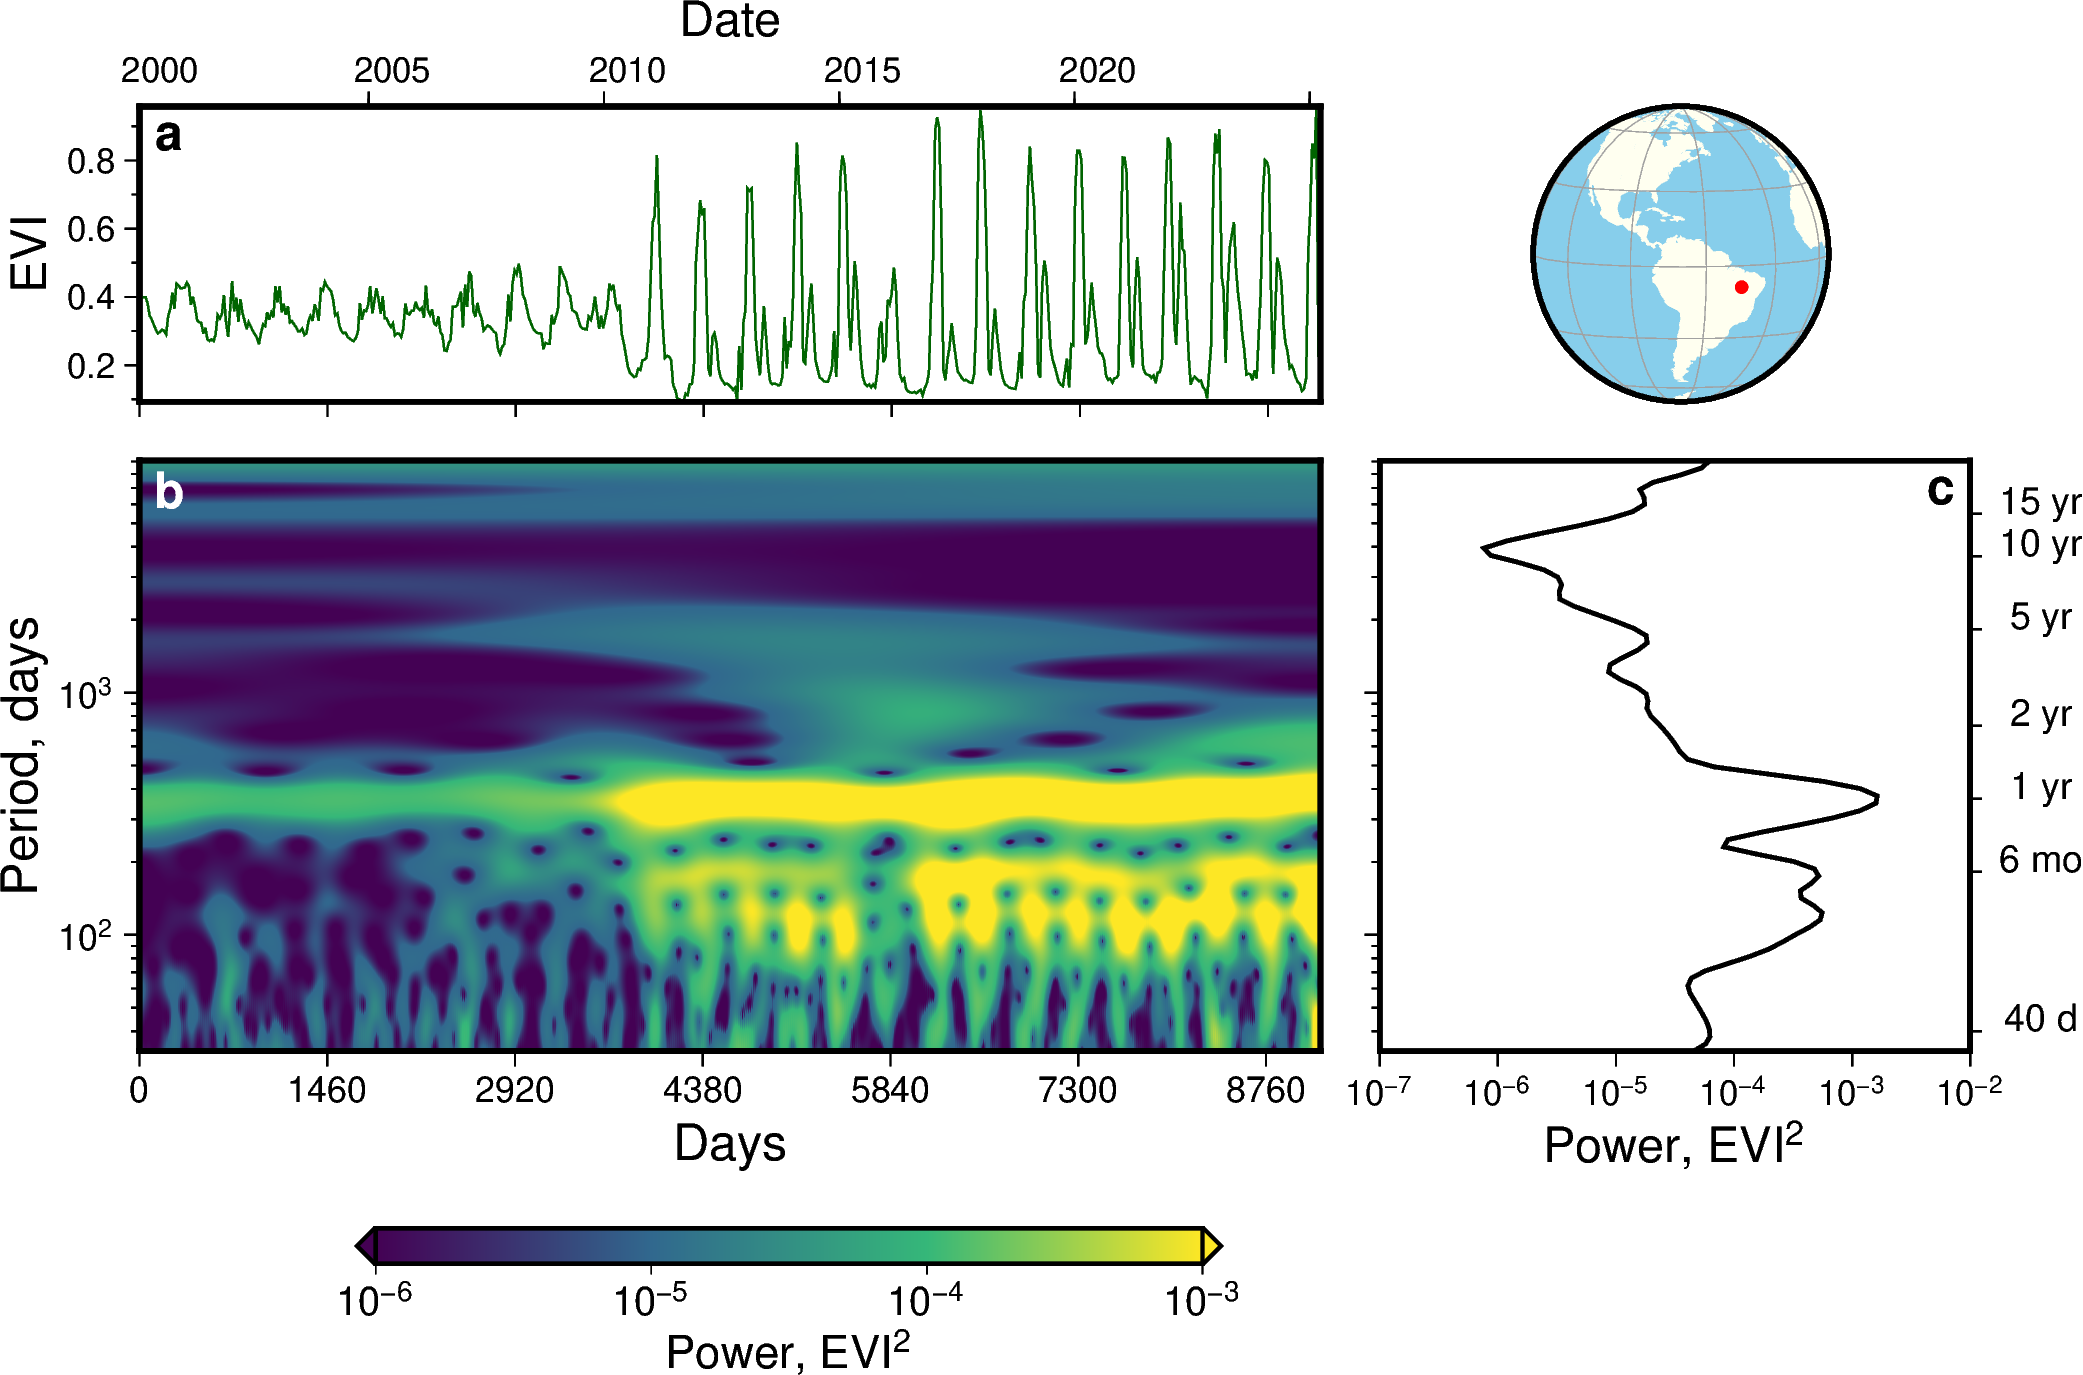

In [21]:
fig=pygmt.Figure()

# A ### Plot the synthetic signal ###
fig.basemap(frame=["xa1460+lDays", "ya0.2f0.1+lEVI", "Ws"], projection="X10c/2.5c", region=region_signal)
fig.plot(x=time, y=sig1, pen="0.5p,darkgreen")
fig.basemap(region=[0,10,0,5], projection="X10c/2.5c",  frame=["wens"] ) # add the frame again to make sure it is visible and use it for the labelling
fig.text(x=0.25, y=4.5, text="a", font="12p,Helvetica-Bold,black")
# add dates to the x-axis north
fig.basemap(frame=["xa+lDate", "N"], projection="X10c/2.5c", region=region_signal_date)


# C ### Plot the wavelet power - rectified ###
fig.shift_origin(yshift="-5.5c")
fig.basemap(region=region_rectified_power, projection="X10c/5cl", frame=["xa1460+lDays", "ya1f3p+lPeriod, days", "WS"])
fig.grdimage(rect_surf, cmap=palette)
# add the frame again to make sure it is visible
fig.basemap(region=[0,10,0,5], projection="X10c/5c",  frame=["wens"] ) 
fig.text(x=0.25, y=4.75, text="b", font="12p,Helvetica-Bold,white")

# D ### Plot the time averaged wavelet power and fourier ###
fig.shift_origin(xshift="10.5c")
fig.basemap(region=[1e-7, 1e-2, min(wavelet_power_df['period']), max(wavelet_power_df['period'])], projection="X5cl/5cl",  frame=["Sw", 'ya1f3p+lFrequency, days@+-1@+' ,'xa1p+lPower, EVI@+2@+'])
# fig.plot(y=fft_df['frequency'], x=fft_df['power'], pen="0.5p,grey", label="FFT Power Spectrum")
fig.plot(y=sumpower_df['period'], x=sumpower_df['rectified_power'], pen="1p,black", label="Rectified Power") 
fig.basemap(region=[0,10,0,5], projection="X5c/5c",  frame=["wens"] ) 
fig.text(x=9.5, y=4.75, text="c", font="12p,Helvetica-Bold,black")

# add a frame to put periods in days, This is a huge workaround
fig.shift_origin(xshift="5c")
fig.basemap(region=[0,5, wavelet_power_df['period'].min(),wavelet_power_df['period'].max()], projection="X10c/5lc",  frame=["W"] )
ticks = [40, 182, 365, 730, 1825, 3650, 5475]
lables = ['40 d', '6 mo', '1 yr', '2 yr', '5 yr', '10 yr', '15 yr']
# Add custom ticks using annotations
for tick, label in zip(ticks, lables):
    # Add ticks manually using annotations (style 'T' for ticks)
    fig.plot(y=[tick, tick], x=[0, 0.05], pen="0.5p,black")
    # Add text labels below the ticks
    fig.text(y=tick, x=0.3, text=label, font="9p", justify="BC")
fig.text(x=np.median(sorted(sumpower_df['period'].unique())), y=0.9, text="Period", font="12p,black")  

# COLOURBAR
pygmt.config(FONT_ANNOT_PRIMARY="14p", FONT_LABEL="16p")
fig.colorbar(position="JMB+o-15c/1.5c+w7c/0.3c+e",frame="xa1000p+lPower, EVI@+2@+", log=True)

# add a small picture of the world to show the location of the site
fig.shift_origin(xshift="-3.7c", yshift="5.5c")
pygmt.config(MAP_GRID_PEN="gray63")
fig.basemap(region="d", projection="G290/5/2.5c", frame="afg") # brazil
# fig.basemap(region="d", projection="G140/-10/2.5c", frame="afg") # australia
# fig.basemap(region="d", projection="G10/45/2.5c", frame="afg") # Tuscany
# fig.basemap(region="d", projection="G270/38/2.5c", frame="afg") # USA
fig.coast(water="skyblue", land="ivory", resolution="c", area_thresh="10000/0/1", frame="afg")
fig.plot(x= -45.33555915051746, y=-8.39752127849006, style="c0.10c", fill="red", pen="red", label="Sites")

fig.show()
# fig.savefig(f"{picture_dir}/wa_{Site}.png", dpi=600, transparent=True)

Wavelet allows us to track changes over time at the various frequencies (or periodicity) that compose a signal. In the next section of this notebook I demonstrate how we can recontruct the EVI signal by only preserving selected components.

In [22]:
############################################
######## ISOLATING EACH COMPONENT ##########
############################################

# check which scales correspond to my periods of interest:
scales_df

# six months from period 174.47 to 187., which correspond to scales 168.89 to 181.01 
_, _, _, _, _, _, _, _, _, _, _, _, _, _, six_months_component, _, _ = run_full_wavelet_analysis(sig1_0_mean, dt=16, mirror=True, cut1=167, cut2=182, wf='morlet', dj=0.1, om0=6, normmean=False, mirrormethod=3)

# one year, from period 349 to 374., which correspond to scales 337.79 to 362.03
_, _, _, _, _, _, _, _, _, _, _, _, _, _, one_year_component, _, _ = run_full_wavelet_analysis(sig1_0_mean, dt=16, mirror=True, cut1=336, cut2=363, wf='morlet', dj=0.1, om0=6, normmean=False, mirrormethod=3)

# two years, from period 697.9, 748., which correspond to scales 675.58 to 724.07
_, _, _, _, _, _, _, _, _, _, _, _, _, _, two_years_component, _, _ = run_full_wavelet_analysis(sig1_0_mean, dt=16, mirror=True, cut1=674, cut2=725, wf='morlet', dj=0.1, om0=6, normmean=False, mirrormethod=3)

# two years to 7 years, from period 697.9 to 2604., which correspond to scales 675.58 to 2521.38
_, _, _, _, _, _, _, _, _, _, _, _, _, _, enso_component, _, _ = run_full_wavelet_analysis(sig1_0_mean, dt=16, mirror=True, cut1=674, cut2=2522, wf='morlet', dj=0.1, om0=6, normmean=False, mirrormethod=3)

#####################################
### DEALING WITH MIRRORRED RESULT ###
#####################################

# select only the window-filtered recontructed signal from 5th repetition
six_months_component = six_months_component.iloc[start_index:end_index]
six_months_component = six_months_component+np.mean(sig1)+xmirror_df.iloc[0, 0] # add the mean of the original signal

one_year_component = one_year_component.iloc[start_index:end_index]
one_year_component = one_year_component+np.mean(sig1)+xmirror_df.iloc[0, 0] # add the mean of the original signal

two_years_component = two_years_component.iloc[start_index:end_index]
two_years_component = two_years_component+np.mean(sig1)+xmirror_df.iloc[0, 0] # add the mean of the original signal

enso_component = enso_component.iloc[start_index:end_index]
enso_component = enso_component+np.mean(sig1)+xmirror_df.iloc[0, 0] # add the mean of the original signal

Plotting each reconstructed signal:

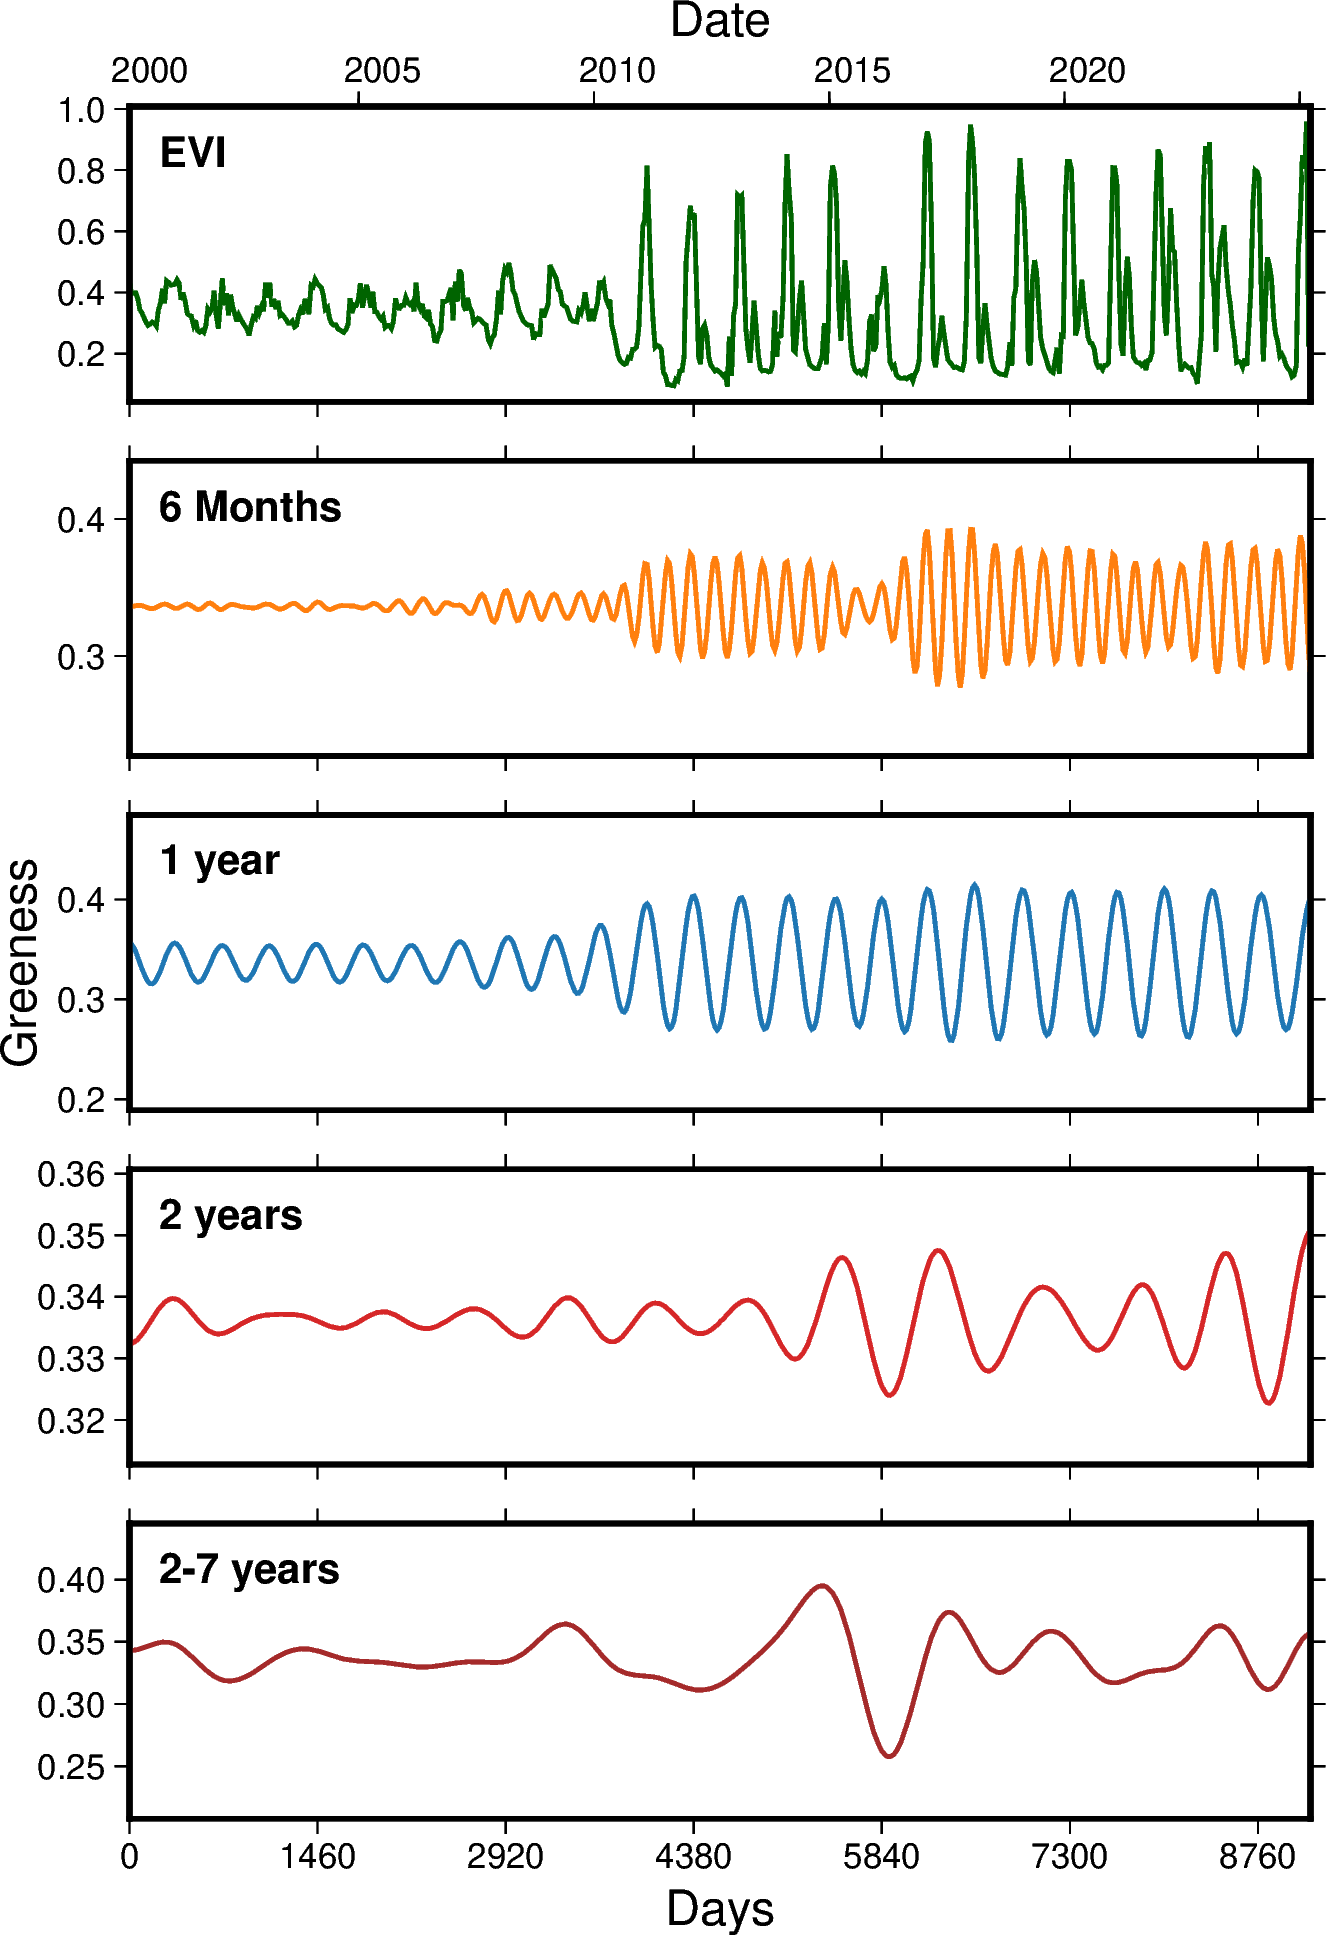

In [23]:
############################################
####### RECONSTRUCTED SIGNAL PLOT ##########
############################################

fig = pygmt.Figure()

region_reconstructed = [min(time), max(time), 0.25, 0.5]
colors = [ "#ff7f0e", "#1f77b4", "#d62728"]


# ### Plot the vegetation signal ###
fig.basemap(frame=["xa1460+lDays", "ya", "We"], projection="X10c/2.5c", region=[min(time), max(time), min(sig1)-0.05, max(sig1)+0.05])
fig.plot(x=time, y=sig1, pen="1p,darkgreen")
fig.basemap(frame=["xa1460+lDays", "se"], projection="X10c/2.5c", region=[min(time), max(time), 0, 5])
fig.basemap(region=[0,10,0,5], projection="X10c/2.5c",  frame=["wens"] ) # add the frame again to make sure it is visible and use it for the labelling
fig.text(x=0.25, y=4.5, text="EVI", font="10p,Helvetica-Bold,black", justify ="LT")
# add dates to the x-axis north
fig.basemap(frame=["xa+lDate", "N"], projection="X10c/2.5c", region=region_signal_date)

# ------------------------------------------------------------------------------------------------------------
fig.shift_origin(yshift="-3c")
fig.basemap(frame=["xa1460+lDays", "ya0.1", "Wen"], projection="X10c/2.5c", region=[min(time), max(time), min(six_months_component["inverse_cwt_part1"])-0.05, max(six_months_component["inverse_cwt_part1"])+0.05])
fig.plot(x=time, y=six_months_component["inverse_cwt_part1"], pen=f"1p,{colors[0]}")
fig.basemap(frame=["xa1460+lDays", "se"], projection="X10c/2.5c", region=[min(time), max(time), 0, 5])
fig.basemap(region=[0,10,0,5], projection="X10c/2.5c",  frame=["w"] ) # add the frame again to make sure it is visible and use it for the labelling
fig.text(x=0.25, y=4.5, text="6 Months", font="10p,Helvetica-Bold,black", justify ="LT")
# ------------------------------------------------------------------------------------------------------------


fig.shift_origin(yshift="-3c")
fig.basemap(frame=["xa1460+lDays", "ya0.1+lGreeness", "Wen"], projection="X10c/2.5c", region=[min(time), max(time), min(one_year_component["inverse_cwt_part1"])-0.07, max(one_year_component["inverse_cwt_part1"])+0.07])
fig.plot(x=time, y=one_year_component["inverse_cwt_part1"], pen=f"1p,{colors[1]}")
fig.basemap(frame=["xa1460+lDays", "se"], projection="X10c/2.5c", region=[min(time), max(time), 0, 5])
fig.basemap(region=[0,10,0,5], projection="X10c/2.5c",  frame=["w"] ) # add the frame again to make sure it is visible and use it for the labelling
fig.text(x=0.25, y=4.5, text="1 year", font="10p,Helvetica-Bold,black", justify ="LT")
# ------------------------------------------------------------------------------------------------------------


fig.shift_origin(yshift="-3c")
fig.basemap(frame=["xa1460+lDays", "ya0.01", "Wen"], projection="X10c/2.5c", region=[min(time), max(time), min(two_years_component["inverse_cwt_part1"])-0.01, max(two_years_component["inverse_cwt_part1"])+0.01])
fig.plot(x=time, y=two_years_component["inverse_cwt_part1"], pen=f"1p,{colors[2]}")
fig.basemap(frame=["xa1460+lDays", "se"], projection="X10c/2.5c", region=[min(time), max(time), 0, 5])
fig.basemap(region=[0,10,0,5], projection="X10c/2.5c",  frame=["w"] ) # add the frame again to make sure it is visible and use it for the labelling
fig.text(x=0.25, y=4.5, text="2 years", font="10p,Helvetica-Bold,black", justify ="LT")
# ------------------------------------------------------------------------------------------------------------

fig.shift_origin(yshift="-3c")
fig.basemap(frame=["xa1460+lDays", "ya0.05", "Wen"], projection="X10c/2.5c", region=[min(time), max(time), min(enso_component["inverse_cwt_part1"])-0.05, max(enso_component["inverse_cwt_part1"])+0.05])
fig.plot(x=time, y=enso_component["inverse_cwt_part1"], pen="1p,brown")
fig.basemap(frame=["xa1460+lDays", "Se"], projection="X10c/2.5c", region=[min(time), max(time), 0, 5])
fig.basemap(region=[0,10,0,5], projection="X10c/2.5c",  frame=["w"] ) # add the frame again to make sure it is visible and use it for the labelling
fig.text(x=0.25, y=4.5, text="2-7 years", font="10p,Helvetica-Bold,black", justify ="LT")
# ------------------------------------------------------------------------------------------------------------


fig.show()
# fig.savefig(f"{picture_dir}/reconstructed_components_{Site}.png", dpi=600, transparent=True)

Next it is the calculation of the power change between window 1 and window 2. First I will reproduce a schematic figure that introduce the concept of Normalised Power. Then I'll proceed to calculate the Normalised Power Change for periodicities of 6-month, 1-year, 2-years, 2-7 years. 

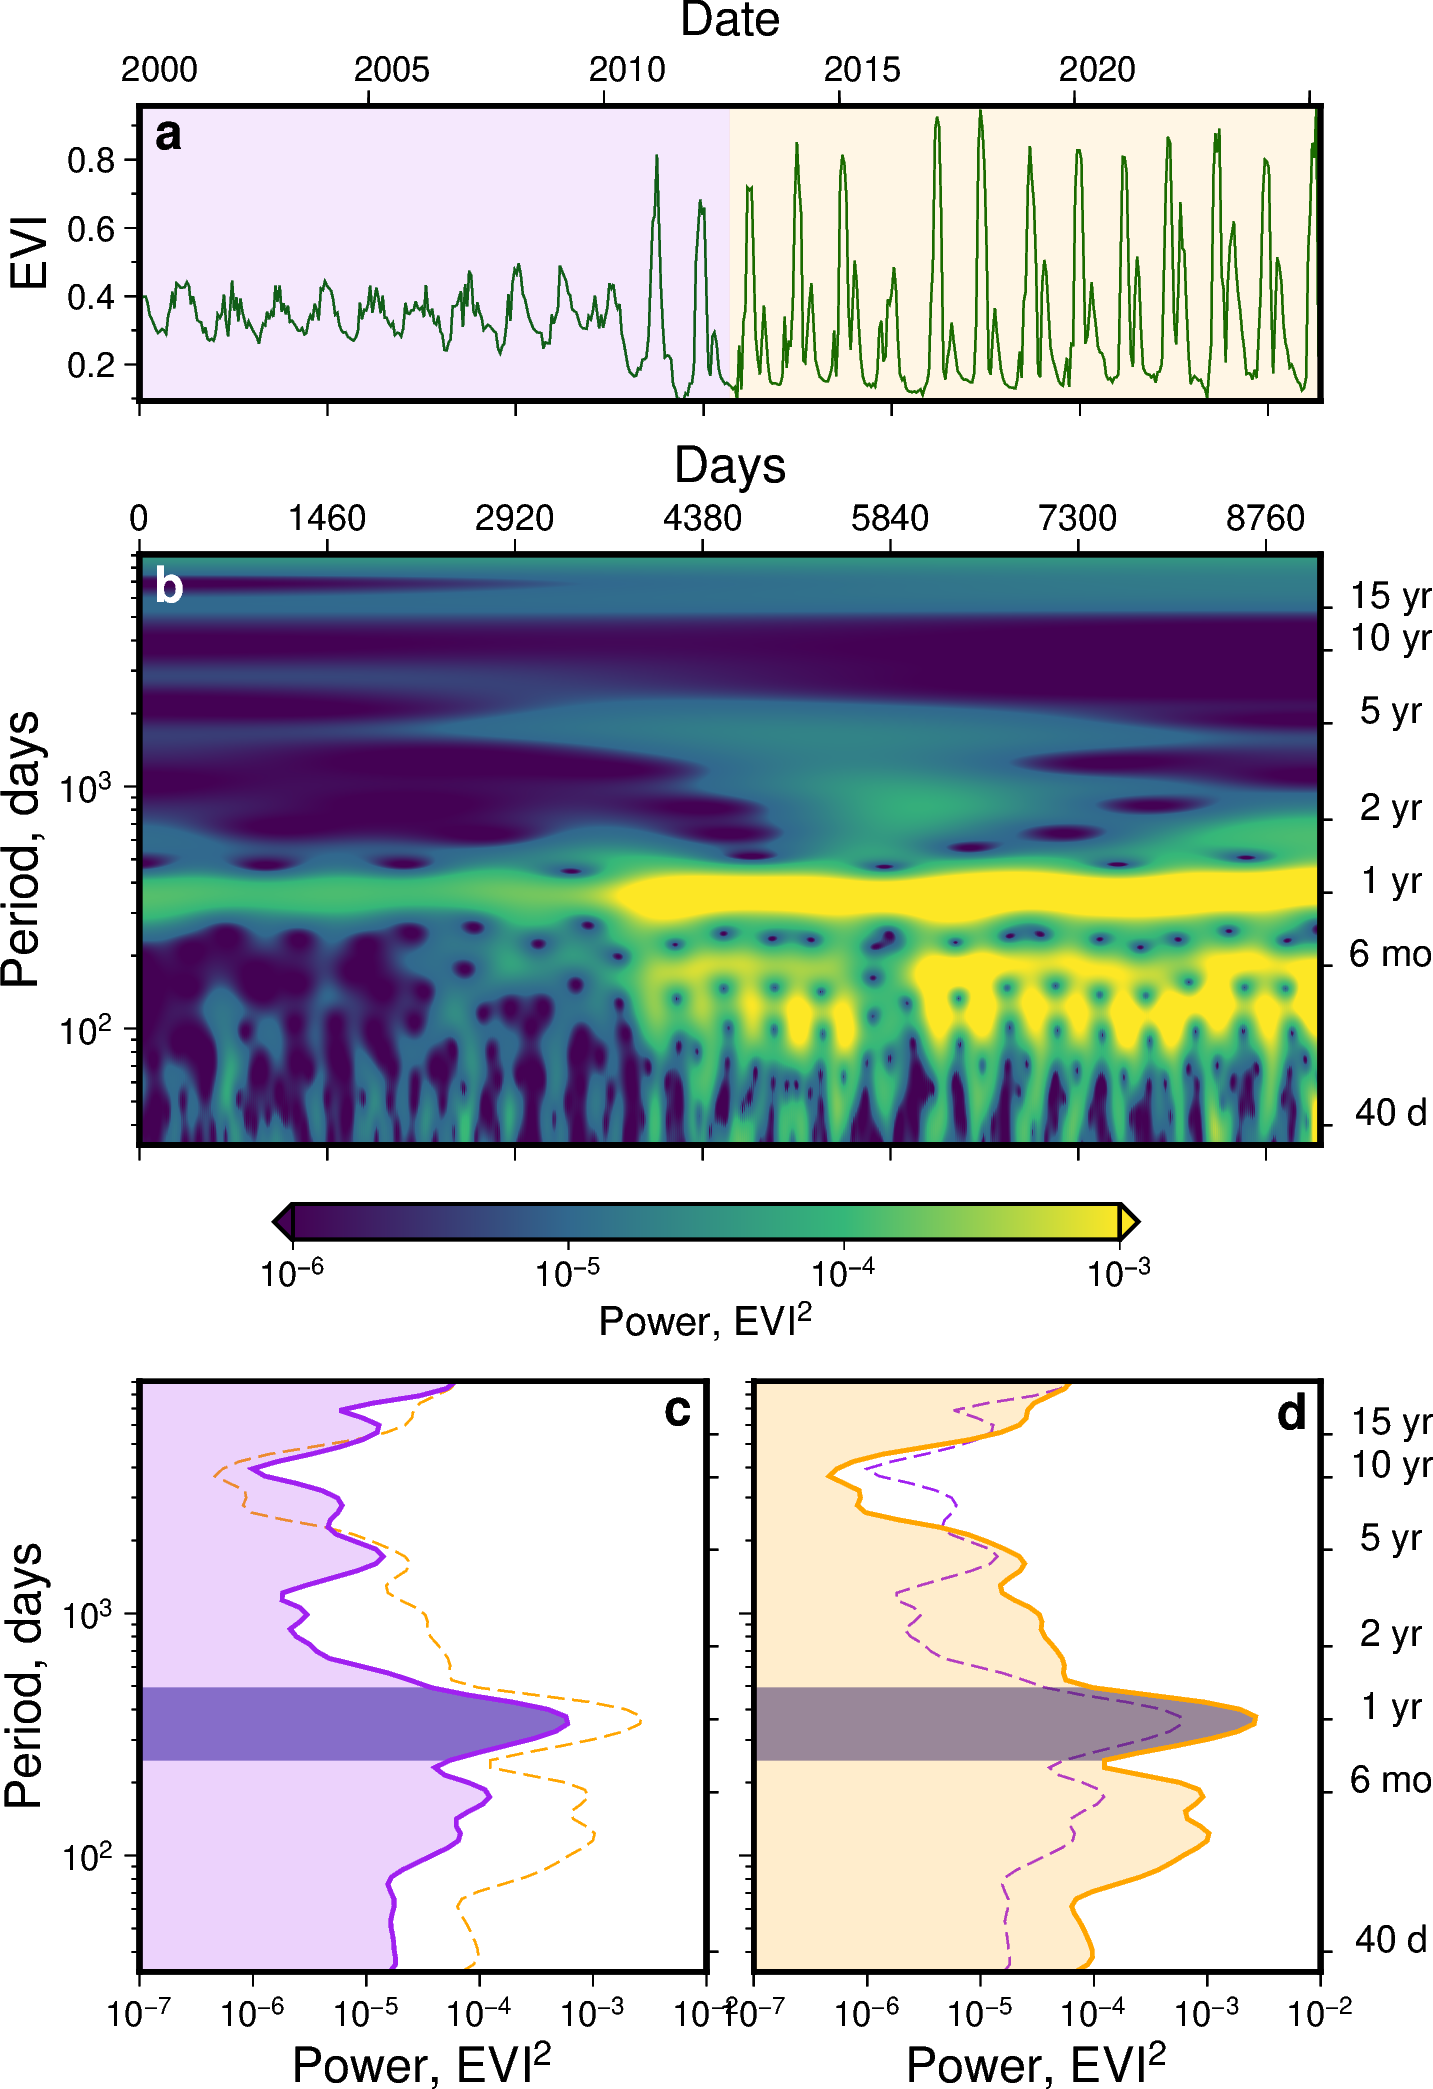

In [24]:
#################################
######## WINDOWED POWER #########
#################################

# define two windows of time:

# define the w1 and w2:
filtered_windows = [
            (0, 4583),
            (4584, 9168)
        ]

# Create a dictionary to store the time-average power for each window
time_average_power = {}
# Loop through the filtered windows and calculate the time-average power
for i, (start, end) in enumerate(filtered_windows):
    # Filter the data for the current window
    filtered_data = wavelet_power_df[
        (wavelet_power_df["time"] >= start) & (wavelet_power_df["time"] <= end)
    ]
    # save the time-average power for the current window
    time_average_power[f"Window {i+1}"] = filtered_data.groupby("period")[["rectified_power", "power"]].mean().reset_index()
    time_average_power[f"Window {i+1}"]["frequency"] = 1 / time_average_power[f"Window {i+1}"]["period"]

# import seaborn as sns
# # Generate a palette of 2 colors with purple and orange from matplotlib
# palette_windows = ["purple", "orange"] 
# hex_palette = sns.color_palette(palette_windows).as_hex()
# sns.palplot(palette_windows)
# plt.show()

#################################
###### create polygon data ######
#################################
def create_filled_polygon_data(x_data, y_data, baseline_x=0):
    """
    Generates a pandas DataFrame for plotting a filled area under a curve 
    in PyGMT by creating a closed polygon.

    Arguments:
        x_data (pd.Series or np.array): The x-coordinates of the curve.
        y_data (pd.Series or np.array): The y-coordinates of the curve.
        baseline_x (float): The x-value where the fill area should stop 
                            (e.g., typically 0).

    Returns:
        pd.DataFrame: A DataFrame containing the coordinates for a closed polygon.
    """
    
    # make sure inputs are numpy arrays for consistent indexing
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    # 1. original data points
    polygon_points = np.column_stack([x_data, y_data])

    # 2. define the closure points:
        # Go from the end of the curve down to the baseline x-value
        # Go from the baseline x-value back up to the start of the curve
    closure_points = np.array([
        [baseline_x, y_data[-1]],
        [baseline_x, y_data[0]]
    ])

    # 3. Combine all points into a single array (numpy)
    full_polygon_coords = np.vstack([polygon_points, closure_points])

    # 4. Convert to a df suitable for plotting
    poly_df = pd.DataFrame(full_polygon_coords, columns=['x', 'y'])
    
    return poly_df

# for Pygmt I need to create polygon data for the filled areas, apply the function above
polygon_data_window_1 = create_filled_polygon_data(
    x_data=time_average_power['Window 1']['rectified_power'],
    y_data=sumpower_df['period'],
    baseline_x=0 
)
polygon_data_window_2 = create_filled_polygon_data(
    x_data=time_average_power['Window 2']['rectified_power'],
    y_data=sumpower_df['period'],
    baseline_x=0
)

poly_yearly_1 = create_filled_polygon_data(
    x_data=time_average_power['Window 1']['rectified_power'][
        (sumpower_df['period'] >= 240) & (sumpower_df['period'] <= 500)
    ],
    y_data=sumpower_df['period'][
        (sumpower_df['period'] >= 240) & (sumpower_df['period'] <= 500)
    ],
    baseline_x=0
)
poly_yearly_2 = create_filled_polygon_data(
    x_data=time_average_power['Window 2']['rectified_power'][
        (sumpower_df['period'] >= 240) & (sumpower_df['period'] <= 500)
    ],
    y_data=sumpower_df['period'][
        (sumpower_df['period'] >= 240) & (sumpower_df['period'] <= 500)
    ],
    baseline_x=0
)   

######################
###### plotting ######
######################
# Now plot the time-averaged power for each window
fig=pygmt.Figure()
colors = ["purple", "orange"]
# A ### Plot the synthetic signal ###
fig.basemap(frame=["xa1460+lDays", "ya0.2f0.1+lEVI", "Ws"], projection="X10c/2.5c", region=region_signal)
fig.plot(x=time, y=sig1, pen="0.5p,darkgreen")
# add rectangle indicating the w1
for i, (start, end) in enumerate(filtered_windows):
    fig.plot(
        data=[[start, -0.01], [end,-0.01],
              [end, 600], [start, 600]],
        fill=f"{colors[i]}",
        close=True, transparency=90)
fig.basemap(region=[0,10,0,5], projection="X10c/2.5c",  frame=["wens"] ) # add the frame again to make sure it is visible and use it for the labelling
fig.text(x=0.25, y=4.5, text="a", font="12p,Helvetica-Bold,black")
# add dates to the x-axis north
fig.basemap(frame=["xa+lDate", "N"], projection="X10c/2.5c", region=region_signal_date)


# C ### Plot the wavelet power - rectified ###
fig.shift_origin(yshift="-6.3c")
fig.basemap(region=region_rectified_power, projection="X10c/5cl", frame=["xa1460+lDays", "ya1f3p+lPeriod, days", "WNs"])
fig.grdimage(rect_surf, cmap=palette)
# add the frame again to make sure it is visible
fig.basemap(region=[0,10,0,5], projection="X10c/5c",  frame=["wens"] ) 
fig.text(x=0.25, y=4.75, text="b", font="12p,Helvetica-Bold,white")

# add a frame to put periods in days, This is a huge workaround
fig.shift_origin(xshift="10c")
fig.basemap(region=[0,5, time_average_power['Window 1']['period'].min(),time_average_power['Window 1']['period'].max()], projection="X10c/5lc",  frame=["W"] )
ticks = [40, 182, 365, 730, 1825, 3650, 5475]
lables = ['40 d', '6 mo', '1 yr', '2 yr', '5 yr', '10 yr', '15 yr']
# Add custom ticks using annotations
for tick, label in zip(ticks, lables):
    # Add ticks manually using annotations (style 'T' for ticks)
    fig.plot(y=[tick, tick], x=[0, 0.05], pen="0.5p,black")
    # Add text labels below the ticks
    fig.text(y=tick, x=0.3, text=label, font="9p", justify="BC")
fig.text(x=np.median(sorted(sumpower_df['period'].unique())), y=0.9, text="Period", font="12p,black")  


# D ### WINDOW 1 Plot the time averaged wavelet power and fourier ###
fig.shift_origin(yshift="-7c", xshift="-10c")
fig.basemap(region=[1e-7, 1e-2, min(time_average_power['Window 1']['period']), max(time_average_power['Window 1']['period'])], projection="X4.8cl/5cl",  frame=["SW", 'ya1f3p+lPeriod, days' ,'xa1p2+lPower, EVI@+2@+'])
fig.plot(y=time_average_power['Window 2']['period'], x=time_average_power['Window 2']['rectified_power'], pen="0.5p,orange,-", label="Rectified Power")
fig.plot(data=poly_yearly_1, fill="navy@50", pen="1p,navy@100", label="1 year component")
fig.plot(data=polygon_data_window_1, fill="purple@80",pen="1p,purple",label="Rectified Power")
fig.basemap(region=[0,10,0,5], projection="X4.8c/5c",  frame=["wens"] ) 
fig.text(x=9.5, y=4.75, text="c", font="12p,Helvetica-Bold,black")


# E ### WINDOW 2 Plot the time averaged wavelet power and fourier ###
fig.shift_origin(xshift="5.2c")
fig.basemap(region=[1e-7, 1e-2, min(time_average_power['Window 2']['period']), max(time_average_power['Window 2']['period'])], projection="X4.8cl/5cl",  frame=["Sw", 'ya1f3p+lPeriod, days' ,'xa1p2+lPower, EVI@+2@+'])
fig.plot(y=time_average_power['Window 1']['period'], x=time_average_power['Window 1']['rectified_power'], pen="0.5p,purple,-", label="Rectified Power")
fig.plot(data=poly_yearly_2, fill="navy@50", pen="1p,navy@100", label="1 year component")
fig.plot(data=polygon_data_window_2, fill="orange@80",pen="1p,orange",label="Rectified Power")
fig.basemap(region=[0,10,0,5], projection="X4.8c/5c",  frame=["wens"] ) 
fig.text(x=9.5, y=4.75, text="d", font="12p,Helvetica-Bold,black")

# add a frame to put periods in days, This is a huge workaround WINDOW 2 
fig.shift_origin(xshift="4.8c")
fig.basemap(region=[0,5, time_average_power['Window 2']['period'].min(),time_average_power['Window 2']['period'].max()], projection="X10c/5lc",  frame=["W"] )
ticks = [40, 182, 365, 730, 1825, 3650, 5475]
lables = ['40 d', '6 mo', '1 yr', '2 yr', '5 yr', '10 yr', '15 yr']
# Add custom ticks using annotations
for tick, label in zip(ticks, lables):
    # Add ticks manually using annotations (style 'T' for ticks)
    fig.plot(y=[tick, tick], x=[0, 0.05], pen="0.5p,black")
    # Add text labels below the ticks
    fig.text(y=tick, x=0.3, text=label, font="9p", justify="BC")
fig.text(x=np.median(sorted(sumpower_df['period'].unique())), y=0.9, text="Period", font="12p,black")

# add a frame to put periods in days, This is a huge workaround WINDOW 1
fig.shift_origin(xshift="-5.2c")
fig.basemap(region=[0,5, time_average_power['Window 1']['period'].min(),time_average_power['Window 1']['period'].max()], projection="X10c/5lc",  frame=["W"] )
ticks = [40, 182, 365, 730, 1825, 3650, 5475]
lables = ['40 d', '6 mo', '1 yr', '2 yr', '5 yr', '10 yr', '15 yr']
# Add custom ticks using annotations
for tick, label in zip(ticks, lables):
    # Add ticks manually using annotations (style 'T' for ticks)
    fig.plot(y=[tick, tick], x=[0, 0.05], pen="0.5p,black")  


# COLOURBAR
pygmt.config(FONT_ANNOT_PRIMARY="12p", FONT_LABEL="14p")
fig.colorbar(position="JMB+o-5c/-6.5c+w7c/0.3c+e",frame="xa1000p+lPower, EVI@+2@+", log=True)


fig.show()
# fig.savefig(f"{picture_dir}/{Site}_window1_vs_window2.png", dpi=600, transparent=True)

In [25]:
###########################################
######## NORMALISED POWER CHANGE ##########
###########################################

# Make dictionary with periods
periods_dict = {
    "6-months": [168.89, 181.01],
    "1-year": [337.79, 362.03],
    "2-years": [675.58, 724.07], 
    "2-7 years": [675.58, 2521.38]
}

# filter the time average power and sum power for the periods of interest
def normalised_power(power_df, periods):
    # filter the power df for the periods of interest
    filtered_power = power_df[
        (power_df["period"] >= periods[0]) & 
        (power_df["period"] <= periods[1])
    ]
    # calculate the sum of the power in the filtered range
    power_sum = filtered_power["rectified_power"].sum()
    
    # calculate the normalised power by dividing by the total power
    total_power = power_df["rectified_power"].sum()
    
    # calculate normalised power
    normalised_power = (power_sum / total_power) * 100
    
    return normalised_power


# calculation of normalised power change between window 1 and window 2 for EVI timeseries from Site 5
for component, periods in periods_dict.items():
    power_w1 = normalised_power(time_average_power['Window 1'], periods)
    power_w2 = normalised_power(time_average_power['Window 2'], periods)
    normalised_change = power_w2 - power_w1
    
    print(f"Normalised Power Change for {component} periodicity component between the two time windows is {normalised_change:.2f}")
    

# absolute power change between window 1 and window 2 for EVI timeseries from Site 5
for component, periods in periods_dict.items():
    power_w1 = time_average_power['Window 1'][
        (time_average_power['Window 1']["period"] >= periods[0]) & 
        (time_average_power['Window 1']["period"] <= periods[1])
    ]["rectified_power"].sum()
    
    power_w2 = time_average_power['Window 2'][
        (time_average_power['Window 2']["period"] >= periods[0]) & 
        (time_average_power['Window 2']["period"] <= periods[1])
    ]["rectified_power"].sum()
    
    absolute_change = power_w2 - power_w1
    
    print(f"Absolute Power Change for {component} periodicity component between the two time windows is {absolute_change:.4f}")

Normalised Power Change for 6-months periodicity component between the two time windows is 1.01
Normalised Power Change for 1-year periodicity component between the two time windows is -2.55
Normalised Power Change for 2-years periodicity component between the two time windows is 0.11
Normalised Power Change for 2-7 years periodicity component between the two time windows is -0.44
Absolute Power Change for 6-months periodicity component between the two time windows is 0.0008
Absolute Power Change for 1-year periodicity component between the two time windows is 0.0020
Absolute Power Change for 2-years periodicity component between the two time windows is 0.0000
Absolute Power Change for 2-7 years periodicity component between the two time windows is 0.0003


### Discussion
At this site, the yearly EVI component increased from w1 to w2 in absolute terms (+ 0.0020). However, when looking at each component relative to the total EVI power (aka Normalised Power), the pattern is different: the 6-month and 1-year components increased, while the 1-year periodicity component decreased in relative terms (- 2.55).
This shows that, even though the total EVI went up, it is the distribution of power among the components that has shifted.